<a href="https://colab.research.google.com/github/muthyalasairam6/ML-PROJECTS/blob/main/FITNESS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/megaGymDataset.csv')

df.head()

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [ ]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(2918, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   object 
 2   Desc        1368 non-null   object 
 3   Type        2918 non-null   object 
 4   BodyPart    2918 non-null   object 
 5   Equipment   2886 non-null   object 
 6   Level       2918 non-null   object 
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 205.3+ KB
None
Unnamed: 0       0
Title            0
Desc          1550
Type             0
BodyPart         0
Equipment       32
Level            0
Rating        1887
RatingDesc    2056
dtype: int64


In [ ]:
print(df['Title'].value_counts())

Title
Band-suspended kettlebell bench press            3
Seated Cable Rows                                3
Seated rear delt fly                             2
Exercise Ball Cable Crunch - Gethin Variation    2
Decline bar press sit-up                         2
                                                ..
Suspended push-up                                1
Push Up to Side Plank                            1
Isometric Chest Squeezes                         1
Side-to-side push-up                             1
Clock push-up                                    1
Name: count, Length: 2909, dtype: int64


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
print(df.isnull().sum())

Unnamed: 0       0
Title            0
Desc          1550
Type             0
BodyPart         0
Equipment       32
Level            0
Rating           0
RatingDesc    2056
dtype: int64


In [ ]:
X = df.drop('Title', axis=1)
y = df['Title']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)

['1.5-rep push-up' '3/4 sit-up' '30 Arms BFR Close-Grip Push-Up' ...
 'Yoga plex' 'Yoke Walk' 'Zercher squat']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2334, 8)
(584, 8)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Type'] = le.fit_transform(df['Type'])
df['BodyPart'] = le.fit_transform(df['BodyPart'])
df['Equipment'] = le.fit_transform(df['Equipment'])
df['Level'] = le.fit_transform(df['Level'])

In [ ]:
print(X.columns)

Index(['Unnamed: 0', 'Desc', 'Type', 'BodyPart', 'Equipment', 'Level',
       'Rating', 'RatingDesc'],
      dtype='object')


In [ ]:
df = df.drop(['Desc', 'RatingDesc'], axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_title = LabelEncoder()
le_body = LabelEncoder()
le_equipment = LabelEncoder()
le_level = LabelEncoder()

df['Title'] = le_title.fit_transform(df['Title'])
df['BodyPart'] = le_body.fit_transform(df['BodyPart'])
df['Equipment'] = le_equipment.fit_transform(df['Equipment'])
df['Level'] = le_level.fit_transform(df['Level'])

In [ ]:
y = df['Type']
X = df.drop('Type', axis=1)

In [ ]:
le_type = LabelEncoder()
y = le_type.fit_transform(df['Type'])
X = df.drop('Type', axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9246575342465754


In [ ]:
print(X_train.dtypes)

Unnamed: 0      int64
Title           int64
BodyPart        int64
Equipment       int64
Level           int64
Rating        float64
dtype: object


In [ ]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'Title', 'Type', 'BodyPart', 'Equipment', 'Level', 'Rating']


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'Title', 'Type', 'BodyPart', 'Equipment', 'Level',
       'Rating'],
      dtype='object')


In [ ]:
df = df.drop(columns=['Desc', 'RatingDesc'], errors='ignore')

In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'Title', 'Type', 'BodyPart', 'Equipment', 'Level', 'Rating']


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print(df.dtypes)

Unnamed: 0      int64
Title           int64
Type            int64
BodyPart        int64
Equipment       int64
Level           int64
Rating        float64
dtype: object


In [ ]:
df = df.drop(['Desc', 'RatingDesc'], axis=1)

KeyError: "['Desc', 'RatingDesc'] not found in axis"

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'Title', 'Type', 'BodyPart', 'Equipment', 'Level', 'Rating']


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM
svm = SVC()

svm.fit(X_train_scaled, y_train)

# Predict
svm_pred = svm.predict(X_test_scaled)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

mlp_pred = mlp.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

def evaluate_model(name, y_test, pred):

    print("\n",name)

    print("Accuracy:",
          accuracy_score(y_test,pred))

    print("Precision:",
          precision_score(y_test,pred,
                          average='weighted'))

    print("Recall:",
          recall_score(y_test,pred,
                       average='weighted'))

    print("F1 Score:",
          f1_score(y_test,pred,
                   average='weighted'))

In [ ]:
evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("SVM", y_test, svm_pred)

evaluate_model("KNN", y_test, knn_pred)

evaluate_model("MLP", y_test, mlp_pred)

evaluate_model("XGBoost", y_test, xgb_pred)


 Random Forest
Accuracy: 0.9246575342465754
Precision: 0.91955149748609
Recall: 0.9246575342465754
F1 Score: 0.9180855721110793

 SVM
Accuracy: 0.9075342465753424
Precision: 0.8693531385887039
Recall: 0.9075342465753424
F1 Score: 0.8810175622380203

 KNN
Accuracy: 0.8921232876712328
Precision: 0.8969030205534733
Recall: 0.8921232876712328
F1 Score: 0.8879395065381475

 MLP
Accuracy: 0.9092465753424658
Precision: 0.8876346855831935
Recall: 0.9092465753424658
F1 Score: 0.8933875187405763

 XGBoost
Accuracy: 0.9315068493150684
Precision: 0.9316542094206296
Recall: 0.9315068493150684
F1 Score: 0.9281967694163656


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

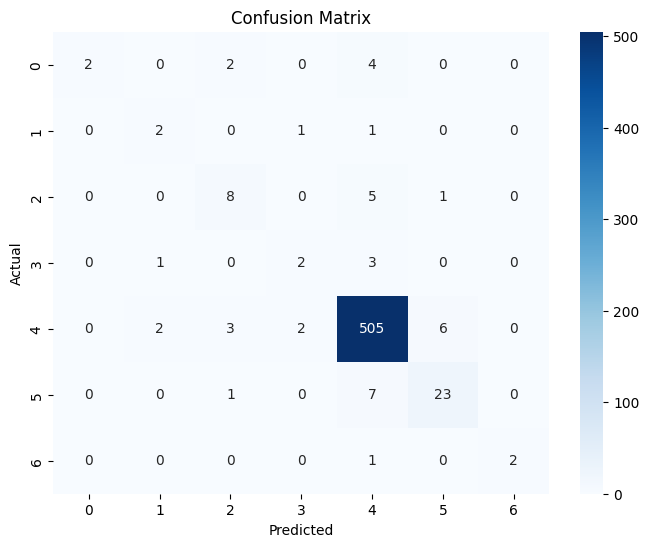

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    xgb_pred
))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.40      0.50      0.44         4
           2       0.57      0.57      0.57        14
           3       0.40      0.33      0.36         6
           4       0.96      0.97      0.97       518
           5       0.77      0.74      0.75        31
           6       1.00      0.67      0.80         3

    accuracy                           0.93       584
   macro avg       0.73      0.58      0.61       584
weighted avg       0.93      0.93      0.93       584



In [ ]:
import joblib

joblib.dump(xgb,
            'fitness_activity_model.pkl')

joblib.dump(scaler,
            'scaler.pkl')

['scaler.pkl']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/megaGymDataset.csv')

print(df.columns)
print(df.head())

Index(['Unnamed: 0', 'Title', 'Desc', 'Type', 'BodyPart', 'Equipment', 'Level',
       'Rating', 'RatingDesc'],
      dtype='object')
   Unnamed: 0                         Title  \
0           0        Partner plank band row   
1           1  Banded crunch isometric hold   
2           2         FYR Banded Plank Jack   
3           3                 Banded crunch   
4           4                        Crunch   

                                                Desc      Type    BodyPart  \
0  The partner plank band row is an abdominal exe...  Strength  Abdominals   
1  The banded crunch isometric hold is an exercis...  Strength  Abdominals   
2  The banded plank jack is a variation on the pl...  Strength  Abdominals   
3  The banded crunch is an exercise targeting the...  Strength  Abdominals   
4  The crunch is a popular core exercise targetin...  Strength  Abdominals   

  Equipment         Level  Rating RatingDesc  
0     Bands  Intermediate     0.0        NaN  
1     Bands  Interme

In [ ]:
import joblib

model = joblib.load("fitness_activity_model.pkl")
scaler = joblib.load("scaler.pkl")

def predict_activity(features):

    scaled = scaler.transform([features])

    prediction = model.predict(scaled)

    return prediction[0]

In [ ]:
print(X_train.shape)

(2334, 6)


In [ ]:
print(X.columns)

Index(['Unnamed: 0', 'Title', 'BodyPart', 'Equipment', 'Level', 'Rating'], dtype='object')


In [ ]:
import pandas as pd

sample = pd.DataFrame({
    'Unnamed: 0':[1],
    'Title':[10],
    'BodyPart':[2],
    'Equipment':[3],
    'Level':[1],
    'Rating':[4.5]
})

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print(prediction)

[4]


In [ ]:
import pandas as pd
from datetime import datetime

def log_workout(exercise,duration,calories):

    data = {
        "Date":[datetime.now()],
        "Exercise":[exercise],
        "Duration":[duration],
        "Calories":[calories]
    }

    df = pd.DataFrame(data)

    try:
        old = pd.read_csv("user_history.csv")

        df = pd.concat([old,df])

    except:
        pass

    df.to_csv("user_history.csv",index=False)

    print("Workout Saved")

In [ ]:
log_workout(
    "Pushup",
    20,
    150
)

Workout Saved


In [ ]:
import pandas as pd

history = pd.read_csv("user_history.csv")

print(history.tail())

                         Date Exercise  Duration  Calories
0  2026-06-21 07:22:34.112253   Pushup        20       150


In [ ]:
def get_stats():

    df = pd.read_csv("user_history.csv")

    total_workouts = len(df)

    total_duration = df["Duration"].sum()

    total_calories = df["Calories"].sum()

    return {
        "Workouts":total_workouts,
        "Duration":total_duration,
        "Calories":total_calories
    }

In [ ]:
print(get_stats())

{'Workouts': 1, 'Duration': np.int64(20), 'Calories': np.int64(150)}


In [ ]:
def recommend(exercise):

    recommendations = {

        "Pushup":
        "Add Plank and Bench Press",

        "Squat":
        "Add Lunges and Deadlift",

        "Plank":
        "Add Mountain Climbers",

        "Deadlift":
        "Add Squats"
    }

    return recommendations.get(
        exercise,
        "Continue Training"
    )

In [ ]:
print(recommend("Squat"))

Add Lunges and Deadlift


In [ ]:
def coach(exercise):

    if exercise=="Pushup":

        return """
        Great upper-body workout.
        Increase reps by 10%.
        Focus on chest and triceps.
        """

    elif exercise=="Squat":

        return """
        Excellent leg workout.
        Increase resistance gradually.
        """

    else:

        return """
        Maintain proper form.
        Stay hydrated.
        """

In [ ]:
import joblib
import pandas as pd

model = joblib.load("fitness_activity_model.pkl")
scaler = joblib.load("scaler.pkl")

In [ ]:
def predict_activity(features):

    scaled = scaler.transform(features)

    prediction = model.predict(scaled)

    return prediction[0]

In [ ]:
import pandas as pd
from datetime import datetime

def log_workout(exercise,duration,calories):

    data = {
        "Date":[datetime.now()],
        "Exercise":[exercise],
        "Duration":[duration],
        "Calories":[calories]
    }

    df = pd.DataFrame(data)

    try:
        old = pd.read_csv("user_history.csv")
        df = pd.concat([old,df])

    except:
        pass

    df.to_csv("user_history.csv",index=False)

    print("Workout Saved")

In [ ]:
def recommend(exercise):

    recommendations = {

        "Pushup":"Add Plank and Bench Press",

        "Squat":"Add Lunges and Deadlift",

        "Plank":"Add Mountain Climbers"
    }

    return recommendations.get(
        exercise,
        "Continue Training"
    )

In [ ]:
print(X.columns)

Index(['Unnamed: 0', 'Title', 'BodyPart', 'Equipment', 'Level', 'Rating'], dtype='object')


In [ ]:
import pandas as pd

sample = pd.DataFrame({
    'Unnamed: 0':[1],
    'Title':[10],
    'BodyPart':[2],
    'Equipment':[3],
    'Level':[1],
    'Rating':[4.5]
})

In [ ]:
exercise = predict_activity(sample)

print("Detected Exercise:", exercise)

log_workout(
    exercise,
    duration=20,
    calories=150
)

print(recommend(exercise))

Detected Exercise: 4
Workout Saved
Continue Training


In [ ]:
!pip install google-generativeai

In [ ]:
import google.generativeai as genai

genai.configure(
    api_key="YOUR_API_KEY"
)

model = genai.GenerativeModel(
    "gemini-1.5-pro"
)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def fitness_agent(exercise):

    advice = recommend(exercise)

    return advice

demo = gr.Interface(
    fn=fitness_agent,
    inputs="text",
    outputs="text"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://297d5e406b10c616fb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
